# Exploratory Data Analysis — Bike Rental Demand

This notebook explores the prepared dataset produced by the Week 1 preprocessing pipeline ([`processing_clean_data.ipynb`](./processing_clean_data.ipynb) / Dagster assets under `src/bike_rental/defs/`). It loads [`../data/output-local/final_dataset.csv`](../data/output-local/final_dataset.csv) and answers four questions that will shape the modeling work in [`02_baseline_linear_regression.ipynb`](./02_baseline_linear_regression.ipynb):

1. What does the **target** (`total_count`) look like — range, skew, scale?
2. What **temporal patterns** drive demand (hour, weekday vs weekend, month)?
3. How does **weather** (temperature, humidity, wind, conditions) relate to demand?
4. Which **features are correlated** with the target, and which features are correlated with each other (multicollinearity risk)?

Each section ends with a short takeaway that feeds into modeling decisions.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

In [2]:
df = pd.read_csv(
    "../data/output-local/final_dataset.csv",
    parse_dates=["datetime", "date"],
)
print(f"Shape: {df.shape}")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
df.head()

Shape: (17379, 15)
Date range: 2011-01-01 00:00:00 → 2012-12-31 23:00:00


,datetime,registered_count,direct_count,total_count,hour,date,day,is_weekend,time_of_day,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,is_holiday
0,2011-01-01 00:00:00,13,3,16,0,2011-01-01,5,True,0,clear,3.3,3.0,81.0,0.0,False
1,2011-01-01 01:00:00,32,8,40,1,2011-01-01,5,True,0,clear,2.3,2.0,80.0,0.0,False
2,2011-01-01 02:00:00,27,5,32,2,2011-01-01,5,True,0,clear,2.3,2.0,80.0,0.0,False
3,2011-01-01 03:00:00,10,3,13,3,2011-01-01,5,True,0,clear,3.3,3.0,75.0,0.0,False
4,2011-01-01 04:00:00,1,0,1,4,2011-01-01,5,True,0,clear,3.3,3.0,75.0,0.0,False


## 1. Dataset structure and quality

Before plotting anything we confirm:
- One row per hour, two full years of data (expected: 17,520 hours; missing hours = gaps in the source).
- No missing values in any column.
- Types match what the pipeline declares.

If any of these fail, the modeling notebook needs to handle imputation or gap-filling. If they pass, we can move straight to feature/target analysis.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   datetime                 17379 non-null  datetime64[us]
 1   registered_count         17379 non-null  int64         
 2   direct_count             17379 non-null  int64         
 3   total_count              17379 non-null  int64         
 4   hour                     17379 non-null  int64         
 5   date                     17379 non-null  datetime64[us]
 6   day                      17379 non-null  int64         
 7   is_weekend               17379 non-null  bool          
 8   time_of_day              17379 non-null  int64         
 9   conditions               17379 non-null  str           
 10  temperature_c            17379 non-null  float64       
 11  perceived_temperature_c  17379 non-null  float64       
 12  humidity                 17379 non-null  fl

In [4]:
missing = df.isna().sum()
expected_hours = (df["datetime"].max() - df["datetime"].min()).total_seconds() / 3600 + 1
print(f"Missing values per column:\n{missing}\n")
print(f"Rows: {len(df)} | Expected hours in range: {int(expected_hours)} | Gap: {int(expected_hours) - len(df)}")

Missing values per column:
datetime                   0
registered_count           0
direct_count               0
total_count                0
hour                       0
date                       0
day                        0
is_weekend                 0
time_of_day                0
conditions                 0
temperature_c              0
perceived_temperature_c    0
humidity                   0
windspeed_kmh              0
is_holiday                 0
dtype: int64

Rows: 17379 | Expected hours in range: 17544 | Gap: 165


**Finding.** Zero missing values across all 15 columns. The hour count is slightly below the calendar-expected hours (a handful of hours have no rental events in either source), which is acceptable — the pipeline does not synthetically fill those gaps and a linear model will simply not see them. No imputation strategy is needed downstream.

## 2. Target variable: `total_count`

`total_count = registered_count + direct_count` is the regression target. We need to know:
- Range and central tendency (informs metric scale).
- Skew (informs whether a log-transform might help the linear model).
- Whether `registered_count` and `direct_count` behave similarly enough to model jointly via `total_count` rather than separately.

In [5]:
df[["total_count", "registered_count", "direct_count"]].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

,total_count,registered_count,direct_count
count,17379.000000,17379.000000,17379.000000
mean,189.463088,153.786869,35.676218
std,181.387599,151.357286,49.305030
min,1.000000,0.000000,0.000000
10%,9.000000,7.000000,1.000000
25%,40.000000,34.000000,4.000000
50%,142.000000,115.000000,17.000000
75%,281.000000,220.000000,48.000000
90%,451.200000,354.000000,92.000000
95%,563.100000,465.000000,138.100000


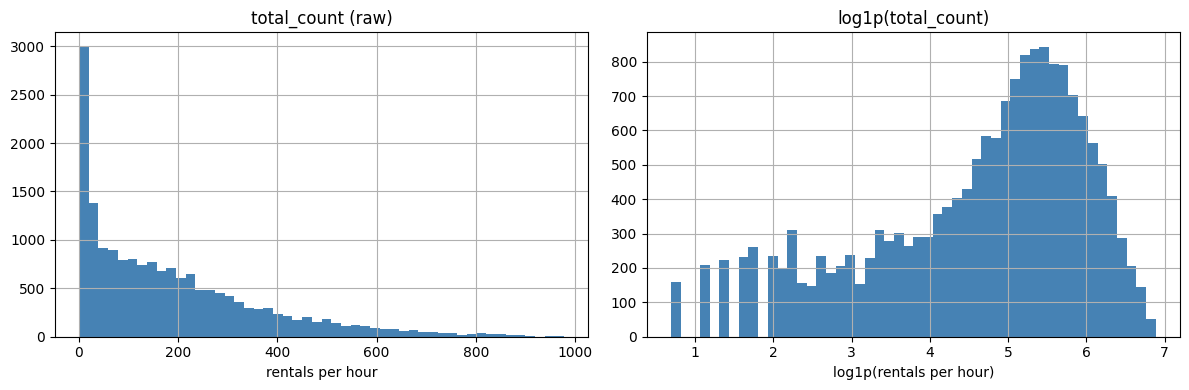

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["total_count"], bins=50, color="steelblue")
axes[0].set_title("total_count (raw)")
axes[0].set_xlabel("rentals per hour")
axes[1].hist(np.log1p(df["total_count"]), bins=50, color="steelblue")
axes[1].set_title("log1p(total_count)")
axes[1].set_xlabel("log1p(rentals per hour)")
plt.tight_layout()
plt.show()

**Finding.** The target is **right-skewed**: median ≈ 142, mean ≈ 189, max = 977, min = 1. The raw histogram is long-tailed; `log1p` makes the distribution roughly bell-shaped. This is worth remembering for model improvement — a linear regressor on `log1p(total_count)` may produce better residuals than on the raw target — but the baseline will use the raw target so the headline metric (RMSE in rentals/hour) is directly interpretable.

## 3. Temporal patterns

Bike demand is driven by *when* people ride. We look at four views:
- **Hour of day** - shows mean rental per hour.
- **Day of week** — is there a weekday/weekend split?
- **Holidays** — is there a split for holidays and non-holidays?
- **Month / year** — seasonality and year-over-year growth.

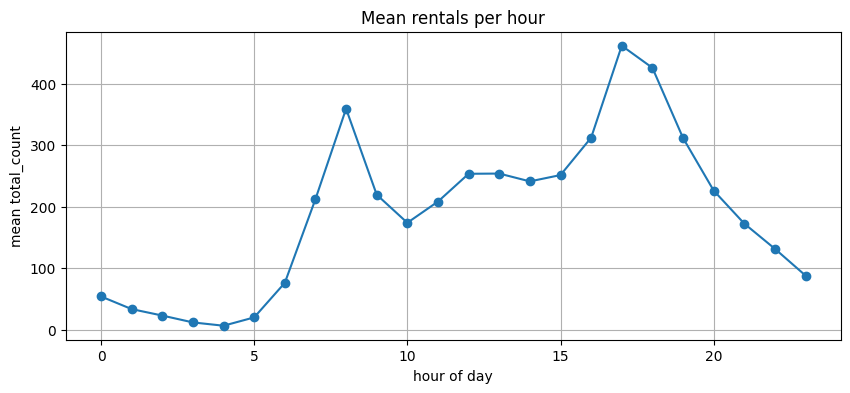

In [7]:
hourly = df.groupby(["hour"])["total_count"].mean()

fig, ax = plt.subplots()
hourly.plot(ax=ax, marker="o")
ax.set_title("Mean rentals per hour")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean total_count")
plt.show()

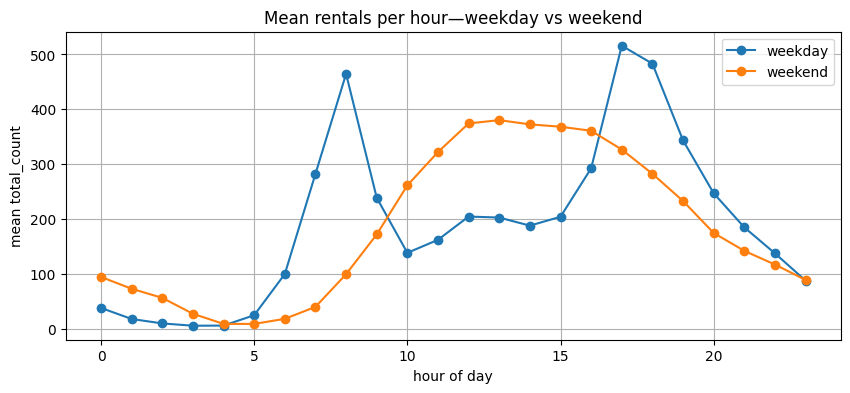

In [8]:
hourly = df.groupby(["is_weekend", "hour"])["total_count"].mean().unstack(0)
hourly.columns = ["weekday", "weekend"]

fig, ax = plt.subplots()
hourly.plot(ax=ax, marker="o")
ax.set_title("Mean rentals per hour—weekday vs weekend")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean total_count")
plt.show()

**Finding.** Two very different shapes:
- **Weekdays** are bimodal with sharp peaks at 8 AM (~465) and 5 PM (~516) — the morning/evening commute.
- **Weekends** are unimodal with a broad midday plateau peaking around 1 PM (~380).

This is a strong **interaction effect** between `hour` and `is_weekend`. A plain linear regression with these two features treated additively cannot fit the bimodal weekday curve — at best it learns an average ramp-up. We expect this to be the dominant source of error for the baseline model, and it motivates non-linear approaches (tree ensembles, or polynomial/cyclic encodings of hour) in the improvement step.

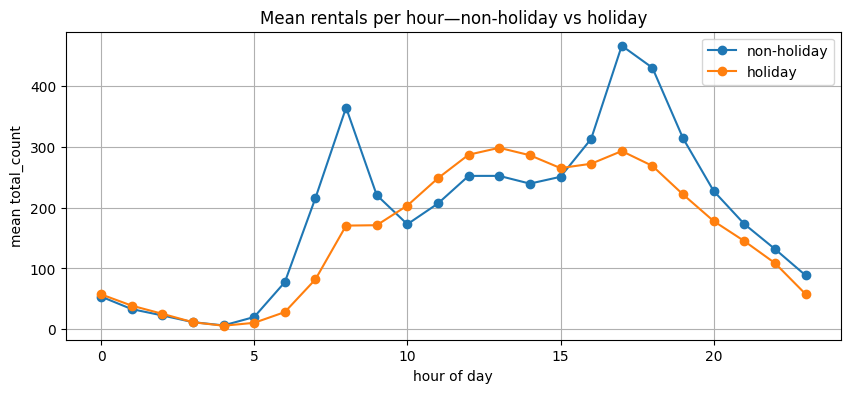

In [9]:
hourly = df.groupby(["is_holiday", "hour"])["total_count"].mean().unstack(0)
hourly.columns = ["non-holiday", "holiday"]

fig, ax = plt.subplots()
hourly.plot(ax=ax, marker="o")
ax.set_title("Mean rentals per hour—non-holiday vs holiday")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean total_count")
plt.show()

**Finding.** :
- **non-holidays** are bimodal just like weekdays in previous chart.
- **holiday** are unimodal with similar counts, only difference is it does not peak at commute times.

The number of holidays in a year is very less and it has no significant effect on the shape or the numbers of mean rental per hours for all days (compare non-holiday's line chart with the first chart in this section). For baseline we will use `is_holiday` feature as it is.

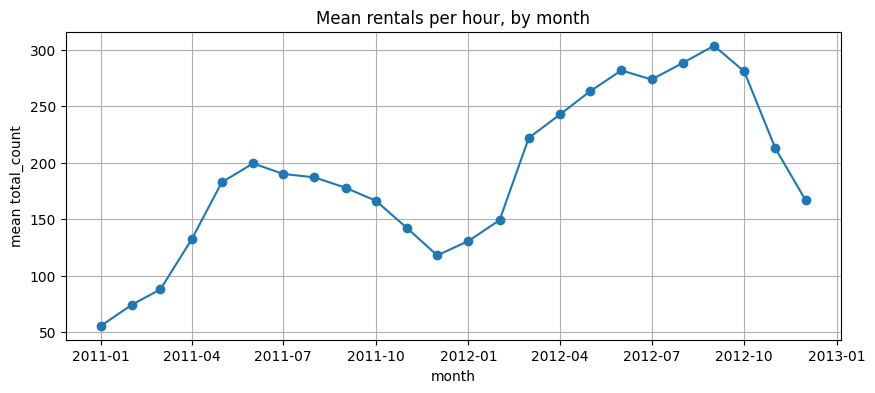

datetime
2011-01     55.507267
2011-02     74.291217
2011-03     87.732877
2011-04    131.947149
2011-05    182.555108
2011-06    199.322222
2011-07    189.974462
2011-08    186.991792
2011-09    177.709902
2011-10    166.232840
2011-11    142.095967
2011-12    117.844804
2012-01    130.558704
2012-02    149.041908
2012-03    221.904441
2012-04    242.651811
2012-05    263.259409
2012-06    281.708333
2012-07    273.665323
2012-08    288.310484
2012-09    303.573611
2012-10    280.848870
2012-11    212.623955
2012-12    166.729111
Freq: M, Name: total_count, dtype: float64

In [10]:
monthly = df.groupby(df["datetime"].dt.to_period("M"))["total_count"].mean()

fig, ax = plt.subplots()
ax.plot(monthly.index.to_timestamp(), monthly.values, marker="o")
ax.set_title("Mean rentals per hour, by month")
ax.set_xlabel("month")
ax.set_ylabel("mean total_count")
plt.show()
monthly

**Finding.** Two effects compounded:
1. **Seasonality**: demand peaks in summer (Jun–Sep) and troughs in winter (Dec–Feb) for both years.
2. **Year-over-year growth**: every 2012 month sits well above its 2011 counterpart (e.g. Jan: 56 → 131, Sep: 178 → 304). The service is growing.

Implication for modeling: the current feature set has no explicit *month* or *year* feature — `temperature_c` will partially absorb seasonality, but YoY growth has no proxy. A time-aware train/test split (last chunk held out) will therefore be **pessimistic** for the linear baseline because the model has not seen the highest-demand months. We accept that pessimism for the baseline and revisit it in feature engineering.

## 4. Weather effects

Four weather columns: categorical `conditions`, plus numeric `temperature_c`, `perceived_temperature_c`, `humidity`, `windspeed_kmh`. We check how each relates to demand.

            count        mean  median
conditions                           
clear       11413  204.869272   159.0
clouds       4544  175.165493   133.0
light_rain   1419  111.579281    63.0
heavy_rain      3   74.333333    36.0


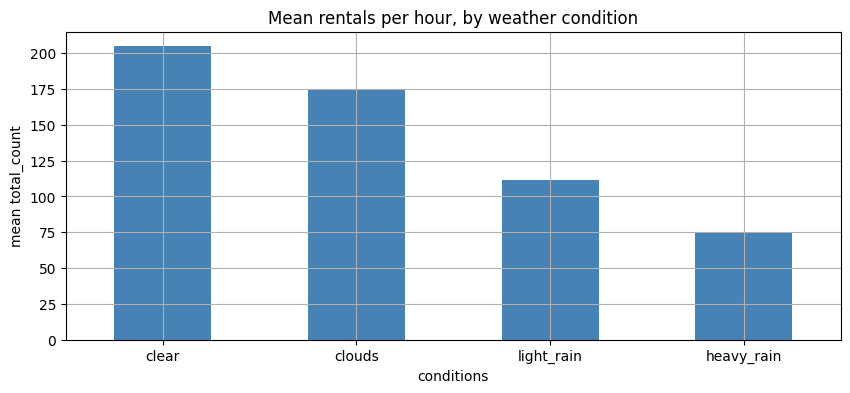

In [11]:
cond_summary = (
    df.groupby("conditions")["total_count"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
print(cond_summary)

fig, ax = plt.subplots()
cond_summary["mean"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Mean rentals per hour, by weather condition")
ax.set_ylabel("mean total_count")
ax.tick_params(axis="x", rotation=0)
plt.show()

**Finding.** Clear monotone ordering: `clear` (≈205) > `clouds` (≈175) > `light_rain` (≈112) > `heavy_rain` (≈74). But `heavy_rain` only has **3 rows** — essentially noise. After one-hot encoding, the `heavy_rain` coefficient will be unreliable; we keep the column anyway because one-hot dropping is cheap and the baseline doesn't need to be clever about rare categories.

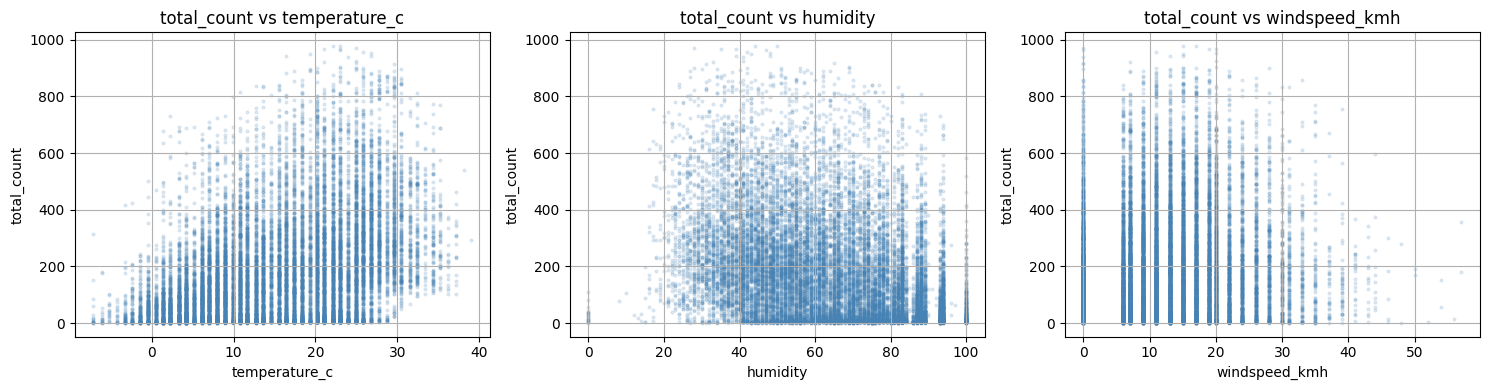

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["temperature_c", "humidity", "windspeed_kmh"]):
    ax.scatter(df[col], df["total_count"], s=4, alpha=0.15, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("total_count")
    ax.set_title(f"total_count vs {col}")
plt.tight_layout()
plt.show()

**Finding.**
- **Temperature**: positive relationship up to ~30°C, then a slight roll-off at the highest temps. A linear coefficient captures the bulk of this; the roll-off is a small non-linearity we ignore for the baseline.
- **Humidity**: clear negative relationship — humid hours suppress demand. Linear is a reasonable approximation.
- **Windspeed**: weak, noisy relationship. The feature is unlikely to contribute much explanatory power on its own.

## 5. Correlations and multicollinearity

Final check before modeling: pairwise Pearson correlations between numeric features and the target, and between features themselves. We are looking for two things:
- Features with non-trivial correlation to `total_count` (candidates for the model).
- Feature pairs with very high mutual correlation (drop one to avoid an unstable linear fit).

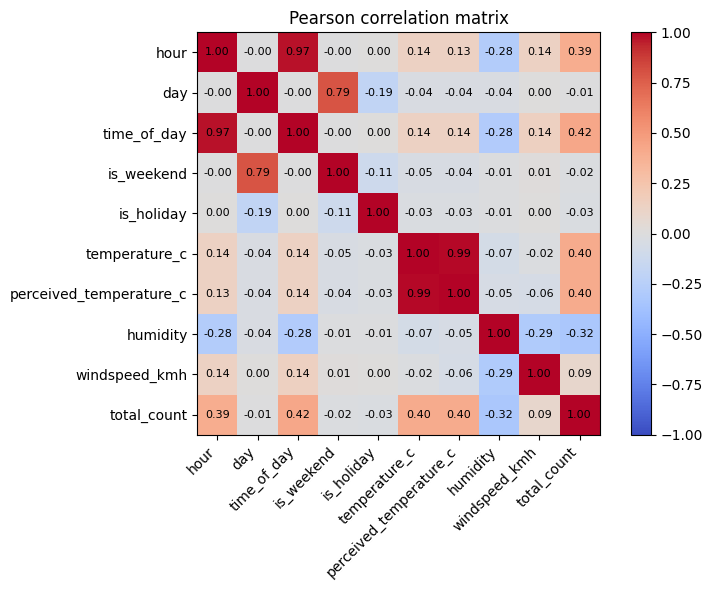

In [13]:
num_cols = [
    "hour", "day", "time_of_day", "is_weekend", "is_holiday",
    "temperature_c", "perceived_temperature_c",
    "humidity", "windspeed_kmh", "total_count",
]
corr = df[num_cols].astype({"is_weekend": int, "is_holiday": int}).corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title("Pearson correlation matrix")
ax.grid(False)
plt.tight_layout()
plt.show()

**Finding.**
- Strongest correlations with `total_count`: `time_of_day` (+0.42), `temperature_c` (+0.41), `perceived_temperature_c` (+0.40), `hour` (+0.39), `humidity` (−0.32).
- **Two strong feature-feature correlations to act on:**
  - `temperature_c` vs `perceived_temperature_c` ≈ 0.99 — textbook multicollinearity. Drop `perceived_temperature_c`.
  - `hour` vs `time_of_day` ≈ 0.97 — `time_of_day` is literally a coarse bucketing of `hour`, so they encode the same signal. Keeping both splits the time-of-day effect across two correlated coefficients without adding information. Drop `time_of_day` and keep the finer-grained `hour`.
- `is_weekend` and `is_holiday` show near-zero linear correlation with the target. This is misleading — from Section 3 we know weekends *reshape* the hourly curve rather than shifting its mean. The linear baseline cannot exploit that interaction; tree models will.

## 6. Takeaways for modeling

What the EDA tells us to do in [`02_baseline_linear_regression.ipynb`](./02_baseline_linear_regression.ipynb):

1. **Target**: model `total_count` directly so the metric (RMSE) is interpretable in rentals/hour. Note the skew — `log1p` is on the table for improvement.
2. **Drop**: `datetime`, `date` (raw time, not usable by a linear model without further engineering), `perceived_temperature_c` (0.99-collinear with `temperature_c`), `time_of_day` (0.97-collinear with `hour`), and the two component counts (`registered_count`, `direct_count`) which would leak the target.
3. **Keep**: `hour`, `day`, `is_weekend`, `is_holiday`, `temperature_c`, `humidity`, `windspeed_kmh`, plus one-hot encoding of `conditions`.
4. **Split**: time-aware (first 80% chronologically train, last 20% test) — the data has growth and seasonality, so a random shuffle would leak future-into-past.
5. **Expected weakness**: the baseline cannot model the hour×weekend interaction or the bimodal commute curve. We will see this clearly in the residuals.